 A window function performs a calculation across a set of table rows that are
 somehow related to the current row.
 This is comparable to the type of calculation that can be done with an aggregate
 function. But unlike regular aggregate functions, use of a window function does not
 cause rows to become grouped into a single output row — the rows retain their
 separate identities.
 Behind the scenes, the window function is able to access more than just the current
 row of the query result.

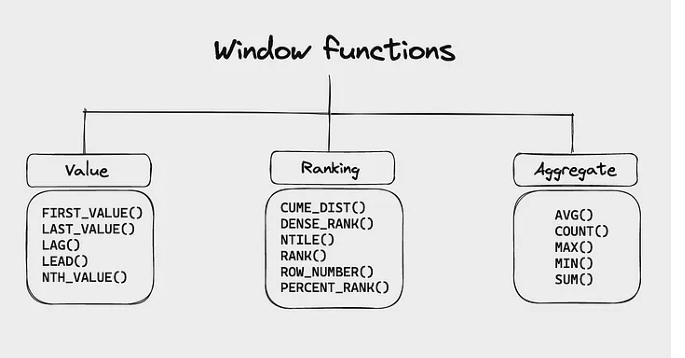

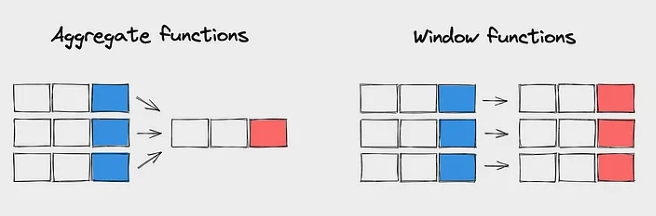

 Partitions: A partition is a way to divide the result set into smaller subsets based
 on one or more columns using the PARTITION BY clause. These subsets are
 treated as separate groups for the window function calculation.

 Windows frame: A window frame defines the range of rows within a partition
 that the window function operates on. The frame is specified using the ROWS ,
 RANGE or GROUPS specification in the window function, and the order is defined
 with ORDER BY

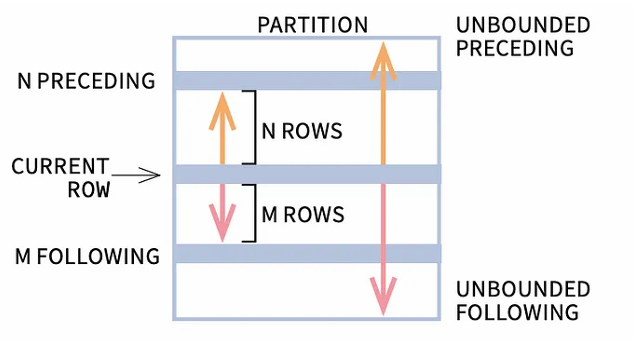

In [1]:
import mysql.connector

mydb2 = mysql.connector.connect(  #establishing the connection
    host = "localhost",
    user="root",
    passwd = "mYsql@2022",
    database = "saleorder"
)

In [2]:
c = mydb2.cursor()

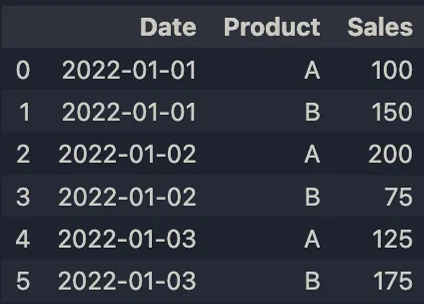

In [ ]:
c.execute(""" SELECT 
Date, 
Product, 
Sales, 
SUM(Sales) OVER (
 PARTITION BY Product 
ORDER BY 
Date
 ) AS RunningTotal 
FROM 
sales 
ORDER BY 
Product; """)

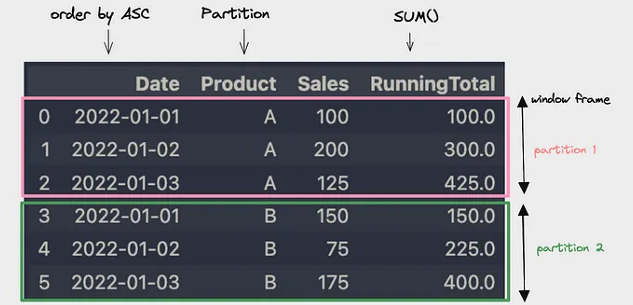

1. Ranking sales representatives by revenue within each region to identify top
 performers.

 2. Categorizing customers into spending tiers based on their purchase percentile
 within a specific time frame.

 3. Calculating a rolling average of daily sales over a specified period to identify
 trends and seasonality.
 
 4. Comparing the current month’s sales to the previous month’s sales for each
 product category to track growth or decline.

A Window is a set (or group) of rows that are related to each-other based on some
 conditions. And window functions are functions that run on each row, and operate
 on each window that a row belongs to.

A “window” is a group of rows that are related to each other

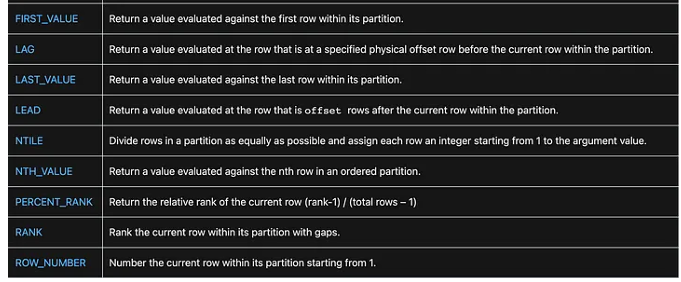

In [3]:
c.execute("""create table tweet(
    id int primary key,
    user_id int,
    content varchar(255),
    created_at datetime
                ) """)

In [4]:
c.execute("""
    INSERT INTO tweet (id, user_id, content, created_at)
    VALUES 
        (1, 101, 'Just had the best coffee of my life!', '2022-01-01 08:00:00'),
        (2, 102, 'Excited for the weekend!', '2022-01-05 12:00:00'),
        (3, 101, 'Just finished a great book!', '2022-01-10 10:00:00'),
        (4, 103, 'Happy birthday to my best friend!', '2022-01-15 09:00:00'),
        (5, 102, 'Just got tickets to my favorite concert!', '2022-01-20 11:00:00'),
        (6, 101, 'Just had a great workout!', '2022-01-25 07:00:00'),
        (7, 104, 'Just tried a new restaurant and loved it!', '2022-02-01 13:00:00'),
        (8, 103, 'Just finished a big project at work!', '2022-02-05 15:00:00'),
        (9, 102, 'Just got engaged!', '2022-02-10 12:00:00'),
        (10, 101, 'Just had a great day at the beach!', '2022-02-15 10:00:00')
""")

In [5]:
mydb2.commit()

 Tweets’ Rolling Averages (Aggregate)
 Given a table below that contains information about tweets over some time,
 calculate the 3-day rolling average of tweets published by each user for each date
 that a tweet was posted.

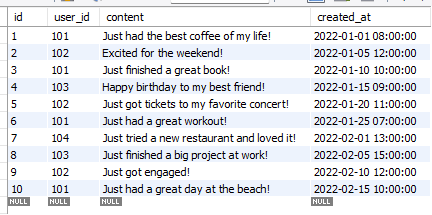

In [7]:
c.execute("""WITH tweet_cnt AS (
 SELECT user_id, created_at,
 COUNT(id) AS tweet_num
 FROM tweet
 GROUP BY user_id, created_at
 )
 SELECT * FROM tweet_cnt;""")

In [8]:
c.fetchall()

[(101, datetime.datetime(2022, 1, 1, 8, 0), 1),
 (102, datetime.datetime(2022, 1, 5, 12, 0), 1),
 (101, datetime.datetime(2022, 1, 10, 10, 0), 1),
 (103, datetime.datetime(2022, 1, 15, 9, 0), 1),
 (102, datetime.datetime(2022, 1, 20, 11, 0), 1),
 (101, datetime.datetime(2022, 1, 25, 7, 0), 1),
 (104, datetime.datetime(2022, 2, 1, 13, 0), 1),
 (103, datetime.datetime(2022, 2, 5, 15, 0), 1),
 (102, datetime.datetime(2022, 2, 10, 12, 0), 1),
 (101, datetime.datetime(2022, 2, 15, 10, 0), 1)]

we need a 3-day rolling average; remember what we learned about window
 frames?
 The window frame we need here is
 ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
 For each date, we get the past two dates and the current date and compute the
 average tweet count.
 Since we want rolling averages for each user, we need to partition on user_id

In [9]:
c.execute(""" SELECT
 user_id,
 created_at,
ROUND(AVG(tweet_num) OVER(
 PARTITION BY user_id
 ORDER BY created_at ASC
 ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
 ), 2) as rolling_avg_3d
 FROM tweet_cnt """)

ProgrammingError: 1146 (42S02): Table 'saleorder.tweet_cnt' doesn't exist

Repeated Payments (Value)

 Sometimes, payment transactions are repeated due to errors.
 Given the transaction table below, identify payments made at the same merchant
 with the same credit card for the same amount within 10 minutes of each other

In [16]:
c.execute("""create table transaction(
    id integer primary key,
    merchant_id int NOT NULL,
    credit_card_number VARCHAR(19) NOT NULL,
    amount decimal(10, 2) NOT NULL,
    created_at timestamp NOT NULL
    )""")

In [17]:
c.execute("""
    INSERT INTO transaction (id, merchant_id, credit_card_number, amount, created_at)
    VALUES 
        (1, 1001, '1234-5678-9012-3456', 10.99, '2022-01-01 08:00:00'),
        (2, 1002, '9876-5432-1098-7654', 20.99, '2022-01-05 12:00:00'),
        (3, 1001, '1234-5678-9012-3456', 5.99, '2022-01-10 10:00:00'),
        (4, 1003, '1111-2222-3333-4444', 50.00, '2022-01-15 09:00:00'),
        (5, 1002, '9876-5432-1098-7654', 15.99, '2022-01-20 11:00:00'),
        (6, 1001, '1234-5678-9012-3456', 25.99, '2022-01-25 07:00:00'),
        (7, 1004, '5555-6666-7777-8888', 30.00, '2022-02-01 13:00:00'),
        (8, 1003, '1111-2222-3333-4444', 40.00, '2022-02-05 15:00:00'),
        (9, 1002, '9876-5432-1098-7654', 60.00, '2022-02-10 12:00:00'),
        (10, 1001, '1234-5678-9012-3456', 75.00, '2022-02-15 10:00:00')
""")

In [18]:
mydb2.commit()

To work out the time difference, we need to obtain the most recent transaction for
 each transaction in the table.
 We can use the LAG() function to get values from the previous row, by default, the
 LAG value is 1.
 Which columns need to be partitioned? In this case, the merchant_id ,
 credit_card_id , and amount 

In [ ]:
c.execute("""SELECT 
    id,
    merchant_id,
    credit_card_number,
    amount,
    created_at,
    LAG(created_at) OVER (
        PARTITION BY merchant_id, credit_card_number, amount 
        ORDER BY created_at
    ) AS previous_created_at
FROM transaction;
""")

In [27]:
c.fetchall()

[(3,
  1001,
  '1234-5678-9012-3456',
  Decimal('5.99'),
  datetime.datetime(2022, 1, 10, 10, 0),
  None),
 (1,
  1001,
  '1234-5678-9012-3456',
  Decimal('10.99'),
  datetime.datetime(2022, 1, 1, 8, 0),
  None),
 (6,
  1001,
  '1234-5678-9012-3456',
  Decimal('25.99'),
  datetime.datetime(2022, 1, 25, 7, 0),
  None),
 (10,
  1001,
  '1234-5678-9012-3456',
  Decimal('75.00'),
  datetime.datetime(2022, 2, 15, 10, 0),
  None),
 (5,
  1002,
  '9876-5432-1098-7654',
  Decimal('15.99'),
  datetime.datetime(2022, 1, 20, 11, 0),
  None),
 (2,
  1002,
  '9876-5432-1098-7654',
  Decimal('20.99'),
  datetime.datetime(2022, 1, 5, 12, 0),
  None),
 (9,
  1002,
  '9876-5432-1098-7654',
  Decimal('60.00'),
  datetime.datetime(2022, 2, 10, 12, 0),
  None),
 (8,
  1003,
  '1111-2222-3333-4444',
  Decimal('40.00'),
  datetime.datetime(2022, 2, 5, 15, 0),
  None),
 (4,
  1003,
  '1111-2222-3333-4444',
  Decimal('50.00'),
  datetime.datetime(2022, 1, 15, 9, 0),
  None),
 (7,
  1004,
  '5555-6666-7777-888

You’re given the employee and department table, and you have to figure out the high
 earners in each department.
 A high earner in a department is an employee who has a salary in the top three
 unique salaries for that department

In [28]:
c.execute("""create table employeedept(
    id int primary key,
    name varchar(50) not null,
    department_id int,
    salary decimal(10, 2)
                ) """)
          
        

In [29]:
c.execute("""
    INSERT INTO employeedept (id, name, department_id, salary)
    VALUES 
        (1, 'John Doe', 101, 50000.00),
        (2, 'Jane Smith', 102, 60000.00),
        (3, 'Bob Johnson', 101, 55000.00),
        (4, 'Alice Williams', 103, 70000.00),
        (5, 'Mike Davis', 102, 65000.00),
        (6, 'Emma Miller', 101, 58000.00),
        (7, 'Tom Wilson', 104, 75000.00),
        (8, 'Sophia Moore', 103, 68000.00),
        (9, 'Oliver Taylor', 102, 72000.00),
        (10, 'Mia Anderson', 101, 60000.00)
""")

In [30]:
mydb2.commit()

 If you guessed DENSE_RANK , you’re right on the nail! We wouldn’t want to skip any
 ranks, and we also want to consider ties in the ranks.
 Now let’s figure out the partition. In this case, it’ll be DepartmentId since it’s by each
 department.
For order, it’s a different case from the previous two case studies; since the ranks are
 in descending order, we need to order by salary from high to low, so we need the
 DESC keyword.

In [35]:
c.execute(""" WITH department_ranking AS (
  SELECT
    Name AS Employee,
    Salary,
    Department_Id,
    DENSE_RANK() OVER (
      PARTITION BY Department_Id 
      ORDER BY Salary DESC
    ) AS rnk
  FROM Employeedept
 )
 SELECT * FROM department_ranking;
 """)

Completed the Query:

Added SELECT * FROM department_ranking; after the CTE to make it a valid statement. This retrieves all columns (Employee, Salary, Department_Id, rnk) from the CTE.

In [33]:
c.fetchall()

[('Mia Anderson', Decimal('60000.00'), 101, 1),
 ('Emma Miller', Decimal('58000.00'), 101, 2),
 ('Bob Johnson', Decimal('55000.00'), 101, 3),
 ('John Doe', Decimal('50000.00'), 101, 4),
 ('Oliver Taylor', Decimal('72000.00'), 102, 1),
 ('Mike Davis', Decimal('65000.00'), 102, 2),
 ('Jane Smith', Decimal('60000.00'), 102, 3),
 ('Alice Williams', Decimal('70000.00'), 103, 1),
 ('Sophia Moore', Decimal('68000.00'), 103, 2),
 ('Tom Wilson', Decimal('75000.00'), 104, 1)]

In [ ]:
c.execute(""" SELECT
  d.Name AS Department,
  r.Employee,
  r.Salary
 FROM department_ranking AS r
 JOIN Department AS d
  ON r.DepartmentId = d.Id

  AND r.rnk <= 3 
ORDER BY 
  d.Name ASC, 
  r.Salary DESC; """)

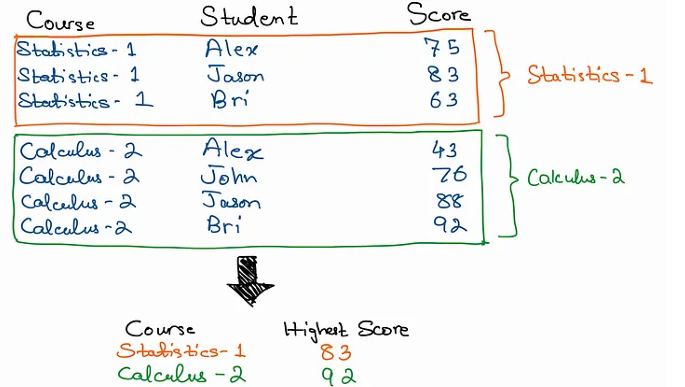

In [ ]:
c.execute("""SELECT Course, MAX(Score) AS Highest_Score
 FROM exam_scores
 GROUP BY Course""")

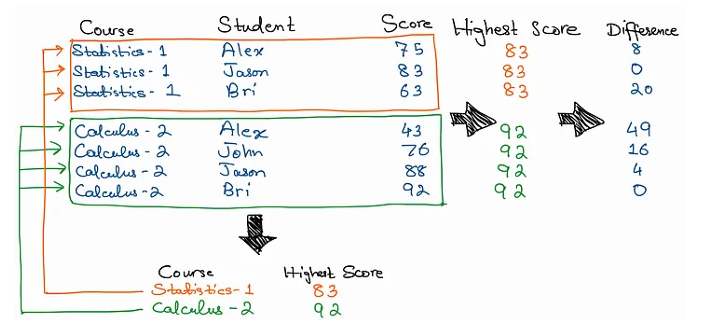

In [ ]:
c.execute(""" SELECT e.Course, e.Student, e.Score, h.Highest_Score, h.Highest_Score - e.Score AS Difference
 FROM exam_scores e
 JOIN (
      SELECT Course, MAX(Score) AS Highest_Score
      FROM exam_scores
      GROUP BY Course
 ) h

 ON e.Course = h.Course""")

Sliding windows — window for rows relative to a given row

Consider an example of a table recording sales at a shop by customers. The data
 contains number of items in each sale, and the total. The requirement is to create a
 column with average number of items sold in last 5 sales before any given sale.
To achieve this, a window needs to be defined, which is called a sliding window. A
 sliding window “slides” with the data i.e. it covers rows relative to each row:

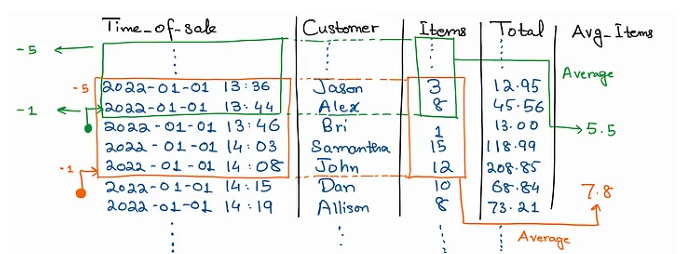

In [ ]:
c.execute(""" SELECT  time_of_sale, customer, items, total,
 AVG(items) OVER (ORDER BY time_of_sale ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING) AS avg
 FROM windowtutorial.sales; """)

In [6]:
import pandas as pd

In [39]:
# pip install pandas

In [40]:
default_series = pd.Series(range(10))

In [41]:
default_series

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
dtype: int64

Rolling

 The DataFrame.rolling() function is used to perform rolling window calculations and is
 generally used in the case of signal processing data and time series data. In the rolling
 function, we take a window size (let's say k) and then perform desired calculations on it.
 Here the window size resembles the number of consecutive values to be taken into
 consideration at a time

In [44]:
default_series.rolling(window=5)

Rolling [window=5,center=False,axis=0,method=single]

In [ ]:
default_series.rolling(window=5).mean() # mean of 5 items and place at 5th position

0    NaN
1    NaN
2    NaN
3    NaN
4    2.0
5    3.0
6    4.0
7    5.0
8    6.0
9    7.0
dtype: float64

In [43]:
default_series.rolling(window=5, center=True).mean()

0    NaN
1    NaN
2    2.0
3    3.0
4    4.0
5    5.0
6    6.0
7    7.0
8    NaN
9    NaN
dtype: float64

In [48]:
data = pd.DataFrame({"x": 1},
 index=[
 pd.Timestamp("20130101 09:00:01"),
 pd.Timestamp("20130101 09:00:02"),
 pd.Timestamp("20130101 09:00:03"),
 pd.Timestamp("20130101 09:00:04"),
 pd.Timestamp("20130101 09:00:06"),
 ],
 )

In [49]:
data

,x
2013-01-01 09:00:01,1
2013-01-01 09:00:02,1
2013-01-01 09:00:03,1
2013-01-01 09:00:04,1
2013-01-01 09:00:06,1


In [50]:
data["right"] = data.rolling("2s", closed="right").x.sum()
data["both"] = data.rolling("2s", closed="both").x.sum()
data["left"] = data.rolling("2s", closed="left").x.sum()
data["neither"] = data.rolling("2s", closed="neither").x.sum()
print(data)

                     x  right  both  left  neither
2013-01-01 09:00:01  1    1.0   1.0   NaN      NaN
2013-01-01 09:00:02  1    2.0   2.0   1.0      1.0
2013-01-01 09:00:03  1    2.0   3.0   2.0      1.0
2013-01-01 09:00:04  1    2.0   3.0   2.0      1.0
2013-01-01 09:00:06  1    1.0   2.0   1.0      NaN


In [7]:
dates = pd.date_range(start = '2020-01-01',end='2020-01-28', freq='d').to_list()

In [8]:
dates

[Timestamp('2020-01-01 00:00:00'),
 Timestamp('2020-01-02 00:00:00'),
 Timestamp('2020-01-03 00:00:00'),
 Timestamp('2020-01-04 00:00:00'),
 Timestamp('2020-01-05 00:00:00'),
 Timestamp('2020-01-06 00:00:00'),
 Timestamp('2020-01-07 00:00:00'),
 Timestamp('2020-01-08 00:00:00'),
 Timestamp('2020-01-09 00:00:00'),
 Timestamp('2020-01-10 00:00:00'),
 Timestamp('2020-01-11 00:00:00'),
 Timestamp('2020-01-12 00:00:00'),
 Timestamp('2020-01-13 00:00:00'),
 Timestamp('2020-01-14 00:00:00'),
 Timestamp('2020-01-15 00:00:00'),
 Timestamp('2020-01-16 00:00:00'),
 Timestamp('2020-01-17 00:00:00'),
 Timestamp('2020-01-18 00:00:00'),
 Timestamp('2020-01-19 00:00:00'),
 Timestamp('2020-01-20 00:00:00'),
 Timestamp('2020-01-21 00:00:00'),
 Timestamp('2020-01-22 00:00:00'),
 Timestamp('2020-01-23 00:00:00'),
 Timestamp('2020-01-24 00:00:00'),
 Timestamp('2020-01-25 00:00:00'),
 Timestamp('2020-01-26 00:00:00'),
 Timestamp('2020-01-27 00:00:00'),
 Timestamp('2020-01-28 00:00:00')]

In [9]:
len(dates)

28

In [10]:

numbers = [47,7,31,1,39,11,15,49,4,14,44,15,13,5,15,4,22,25,47,4,19,3,27,38,47,45,48,50]

In [11]:
len(numbers)

28

In [12]:
df =pd.DataFrame({'Date':dates,"Price":numbers})

In [13]:
df

,Date,Price
0,2020-01-01,47
1,2020-01-02,7
2,2020-01-03,31
3,2020-01-04,1
4,2020-01-05,39
5,2020-01-06,11
6,2020-01-07,15
7,2020-01-08,49
8,2020-01-09,4
9,2020-01-10,14


In [14]:
df.head()

,Date,Price
0,2020-01-01,47
1,2020-01-02,7
2,2020-01-03,31
3,2020-01-04,1
4,2020-01-05,39


moving average

In [15]:
df['Moving_Average'] =df['Price'].rolling(window=5).mean()

In [16]:
df

,Date,Price,Moving_Average
0,2020-01-01,47,NaN
1,2020-01-02,7,NaN
2,2020-01-03,31,NaN
3,2020-01-04,1,NaN
4,2020-01-05,39,25.0
5,2020-01-06,11,17.8
6,2020-01-07,15,19.4
7,2020-01-08,49,23.0
8,2020-01-09,4,23.6
9,2020-01-10,14,18.6


In [17]:
# pip install matplotlib

In [18]:
import matplotlib.pyplot as plt

<Axes: xlabel='Date'>

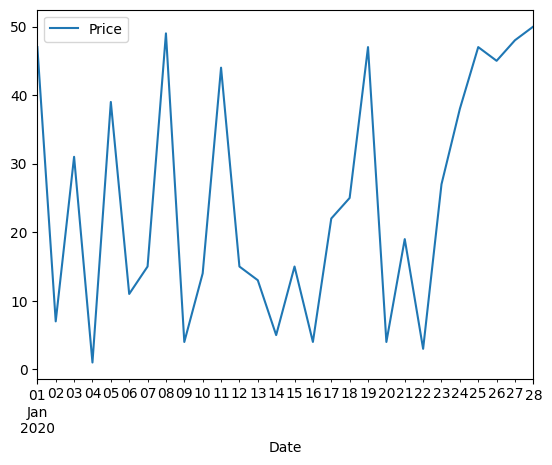

In [21]:
df.plot.line(x='Date',y='Price')

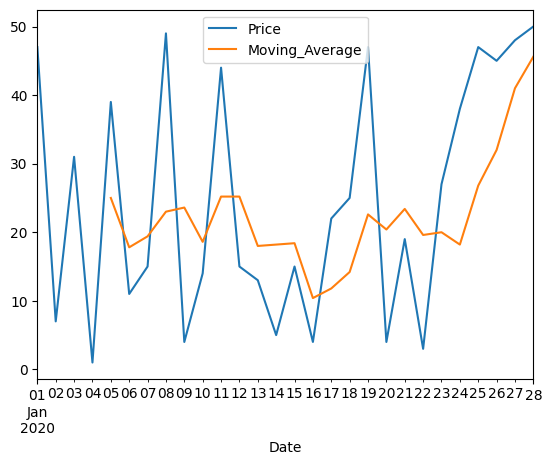

In [ ]:
df.plot.line(x='Date',y=['Price','Moving_Average']);

In [23]:
df['Rolling Average Centre'] = df['Price'].rolling(window=5,center=True).mean()


In [24]:
df

,Date,Price,Moving_Average,Rolling Average Centre
0,2020-01-01,47,NaN,NaN
1,2020-01-02,7,NaN,NaN
2,2020-01-03,31,NaN,25.0
3,2020-01-04,1,NaN,17.8
4,2020-01-05,39,25.0,19.4
5,2020-01-06,11,17.8,23.0
6,2020-01-07,15,19.4,23.6
7,2020-01-08,49,23.0,18.6
8,2020-01-09,4,23.6,25.2
9,2020-01-10,14,18.6,25.2


In [25]:
df['Min Periods'] = df['Price'].rolling(window=5,min_periods=5).mean()

In [26]:
df

,Date,Price,Moving_Average,Rolling Average Centre,Min Periods
0,2020-01-01,47,NaN,NaN,NaN
1,2020-01-02,7,NaN,NaN,NaN
2,2020-01-03,31,NaN,25.0,NaN
3,2020-01-04,1,NaN,17.8,NaN
4,2020-01-05,39,25.0,19.4,25.0
5,2020-01-06,11,17.8,23.0,17.8
6,2020-01-07,15,19.4,23.6,19.4
7,2020-01-08,49,23.0,18.6,23.0
8,2020-01-09,4,23.6,25.2,23.6
9,2020-01-10,14,18.6,25.2,18.6


In [27]:
df['Min Periods'] = df['Price'].rolling(window=5,min_periods=2).mean()

In [28]:
df

,Date,Price,Moving_Average,Rolling Average Centre,Min Periods
0,2020-01-01,47,NaN,NaN,NaN
1,2020-01-02,7,NaN,NaN,27.000000
2,2020-01-03,31,NaN,25.0,28.333333
3,2020-01-04,1,NaN,17.8,21.500000
4,2020-01-05,39,25.0,19.4,25.000000
5,2020-01-06,11,17.8,23.0,17.800000
6,2020-01-07,15,19.4,23.6,19.400000
7,2020-01-08,49,23.0,18.6,23.000000
8,2020-01-09,4,23.6,25.2,23.600000
9,2020-01-10,14,18.6,25.2,18.600000


In [30]:
import numpy as np

In [31]:
ind = pd.date_range(start = '2021-01-01',end='2022-08-23', freq='d').to_list()
cols = ['Open','High','Low','Close','Volume']
df =pd.DataFrame(np.random.rand(600,5),index=ind,columns=cols)
df.index.names=['Date']

In [32]:
df

,Open,High,Low,Close,Volume
Date,,,,,
2021-01-01,0.740230,0.062687,0.049614,0.536264,0.958864
2021-01-02,0.047769,0.302442,0.546093,0.533647,0.606718
2021-01-03,0.886354,0.493565,0.954675,0.326633,0.336460
2021-01-04,0.427065,0.570076,0.708974,0.251163,0.148661
2021-01-05,0.885811,0.195053,0.870360,0.627290,0.661677
...,...,...,...,...,...
2022-08-19,0.307213,0.427694,0.898275,0.791236,0.108930
2022-08-20,0.383958,0.361926,0.125525,0.372134,0.152882
2022-08-21,0.549453,0.138849,0.075665,0.902650,0.916590


In [34]:
df['MV1'] = df.Close.rolling(9).mean()

In [35]:
df

,Open,High,Low,Close,Volume,MV1
Date,,,,,,
2021-01-01,0.740230,0.062687,0.049614,0.536264,0.958864,NaN
2021-01-02,0.047769,0.302442,0.546093,0.533647,0.606718,NaN
2021-01-03,0.886354,0.493565,0.954675,0.326633,0.336460,NaN
2021-01-04,0.427065,0.570076,0.708974,0.251163,0.148661,NaN
2021-01-05,0.885811,0.195053,0.870360,0.627290,0.661677,NaN
...,...,...,...,...,...,...
2022-08-19,0.307213,0.427694,0.898275,0.791236,0.108930,0.618460
2022-08-20,0.383958,0.361926,0.125525,0.372134,0.152882,0.592203
2022-08-21,0.549453,0.138849,0.075665,0.902650,0.916590,0.599036


In [ ]:
df['MV2'] = df.Close.rolling(21).mean()

In [37]:
df

,Open,High,Low,Close,Volume,MV1,MV2
Date,,,,,,,
2021-01-01,0.740230,0.062687,0.049614,0.536264,0.958864,NaN,NaN
2021-01-02,0.047769,0.302442,0.546093,0.533647,0.606718,NaN,NaN
2021-01-03,0.886354,0.493565,0.954675,0.326633,0.336460,NaN,NaN
2021-01-04,0.427065,0.570076,0.708974,0.251163,0.148661,NaN,NaN
2021-01-05,0.885811,0.195053,0.870360,0.627290,0.661677,NaN,NaN
...,...,...,...,...,...,...,...
2022-08-19,0.307213,0.427694,0.898275,0.791236,0.108930,0.618460,0.575795
2022-08-20,0.383958,0.361926,0.125525,0.372134,0.152882,0.592203,0.574468
2022-08-21,0.549453,0.138849,0.075665,0.902650,0.916590,0.599036,0.590965


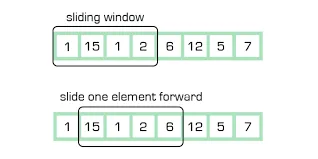

In [40]:
def max_subarray_sum(nums,k):
    max_sum = float('-inf')
    window_sum = sum(nums[:k])
    print(window_sum)
    for i in range(k, len(nums)):
        window_sum = window_sum - nums[i-k] + nums[i]
        print(window_sum)
        max_sum = max(max_sum, window_sum)
    return max_sum

In [41]:
nums = [1, -2, 3, 4, -1, 2, 1, -5, 4]
window_size = 3

max_subarray_sum(nums, window_size)

2
5
6
5
2
-2
0


6

The time complexity of the sliding window technique is usually linear or close to linear, O(n)

The space complexity of the sliding window technique is generally constant, O(1)

Longest Subarray with Sum Less Than K

Problem: Given an array of positive integers and an integer K, find the length of the longest subarray whose sum is less than K.

In [56]:
def maxSubarrayLength(nums, k):
    left, windowSum, maxLength = 0, nums[0], 0 
    
    for right in range(1, len(nums)):
        

        while windowSum > k:
            windowSum -= nums[left]
            left += 1

        maxLength = max(maxLength, right - left + 1)
        
        if left < len(nums) -1:
            windowSum += nums[right+1]
        
    return maxLength
                                                

In [57]:
nums = [1,2,3,4,5,6,7,8,9,10]

k = 15

maxSubarrayLength(nums, k)

5